# EXPLORATORY DATA ANALISYS

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#Load data for the dataset
data = pd.read_csv('Dataset/Final_Dataset.csv')

In [3]:
data.head()

,Date,Births,Euribor,IPC,Price_EURO,Open_EURO,High_EURO,Low_EURO,Defunciones,Debt,...,GDP_Value,Open_DJ,High_DJ,Low_DJ,Close_DJ,Open_y,High_y,Low_y,Close,AdjClose
0,2020-01-02,932,-0.2534,-1.0,1.1170,1.1212,1.1227,1.1163,8.710,1230352.0,...,-5.384,28638.97,28872.80,28627.77,28868.80,9639.099609,9705.400391,9615.099609,9691.200195,9691.200195
1,2020-01-03,932,-0.2534,-1.0,1.1158,1.1172,1.1181,1.1125,8.710,1230352.0,...,-5.384,28553.33,28716.31,28500.36,28634.88,9631.200195,9650.700195,9581.200195,9646.599609,9646.599609
2,2020-01-06,932,-0.2534,-1.0,1.1193,1.1168,1.1207,1.1155,8.710,1230352.0,...,-5.384,28465.50,28708.02,28418.63,28703.38,9585.400391,9618.200195,9492.700195,9600.900391,9600.900391
3,2020-01-06,932,-0.2534,-1.0,1.1193,1.1168,1.1207,1.1155,9.398,1230352.0,...,-5.384,28465.50,28708.02,28418.63,28703.38,9585.400391,9618.200195,9492.700195,9600.900391,9600.900391
4,2020-01-07,932,-0.2534,-1.0,1.1151,1.1198,1.1198,1.1133,8.710,1230352.0,...,-5.384,28639.18,28685.50,28565.28,28583.68,9623.099609,9657.900391,9557.900391,9579.799805,9579.799805


## Correlation matrix

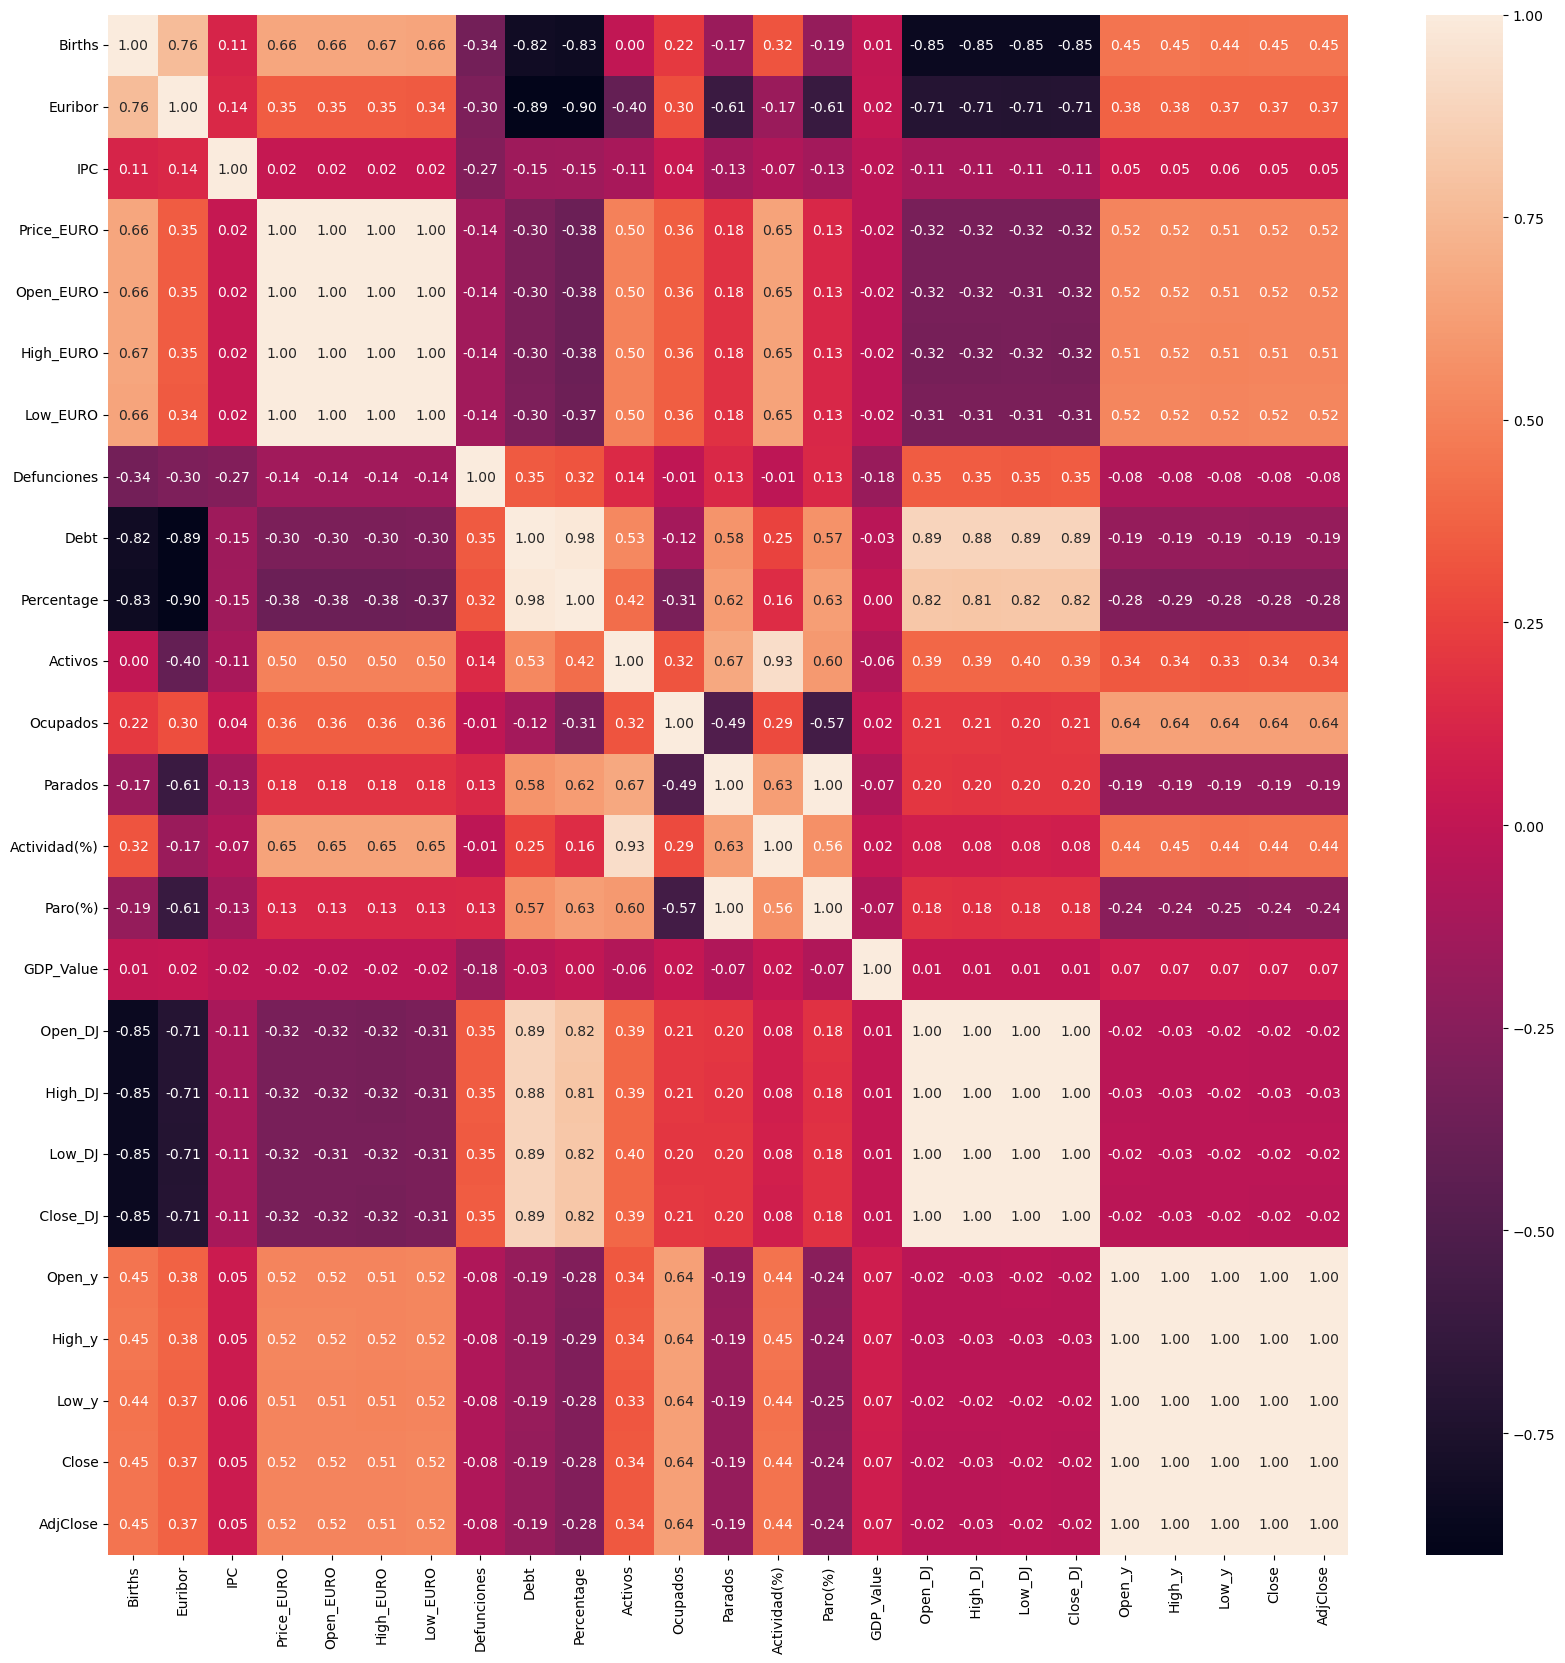

In [14]:
# Create the 'Images' folder if it doesn't exist
images_folder = 'Images'
if not os.path.exists(images_folder):
    os.makedirs(images_folder)

# Correlation matrix between all the factors
plt.figure(figsize=(20, 20))  # Adjust the width and height as needed

cor = sns.heatmap(data[['Date', 'Births', 'Euribor', 'IPC', 'Price_EURO', 'Open_EURO', 'High_EURO', 'Low_EURO', 'Defunciones', 'Debt', 'Percentage', 'Debt_per_capita', 'Activos', 'Ocupados', 'Parados', 'Actividad(%)', 'Paro(%)', 'GDP_Value', ' Open_DJ', ' High_DJ', ' Low_DJ', ' Close_DJ', 'Open_y', 'High_y', 'Low_y', 'Close', 'AdjClose']].corr(), annot=True, fmt=".2f")

# Save the plot in the 'Images' folder
plt.savefig(os.path.join(images_folder, 'heatmap.png'))

# Show the plot
plt.show()

This correlation matrix provides a visual representation of the correlation coefficients between various data variables, which can range from -1 to 1. A correlation of 1 indicates a perfect positive relationship, -1 indicates a perfect negative relationship, and 0 indicates no relationship. Here are some interpretations from this matrix:

The variables 'Births' and 'Euribor' have a strong negative correlation (approximately -0.89), suggesting that when 'Births' increase, 'Euribor' tends to decrease and vice versa.

The 'Debt' variable has little to no correlation with many variables as indicated by the correlation coefficients close to 0. This suggests that 'Debt' does not significantly affect or is not affected by these variables.

The variables 'Percentage' and 'Activos' have a perfect positive correlation with themselves (1.00), which is a standard result for all variables when correlated with themselves.

The 'GDP_Value' appears to have a very weak correlation with most of the variables, with coefficients close to 0, except for 'Paro(%)' (Unemployment Rate) with which it has a moderately negative correlation (approximately -0.43).

The daily stock market variables ('Open_D1', 'High_D1', 'Low_D1', 'Close_D1') are highly positively correlated with each other, with correlation coefficients close to 1. This indicates that these variables tend to move in the same direction.

The correlation between 'Parados' (which could be related to unemployed) and 'Actividad(%)' is perfectly negative (-1.00), indicating an inverse relationship. As 'Parados' increases, 'Actividad(%)' decreases with perfect predictability, and vice versa.

'Paro(%)' and 'Actividad(%)' also have a perfectly negative correlation (-1.00), which makes sense as an increase in unemployment rate would typically result in a decrease in the activity rate.

## IBEX-35 evolution over time

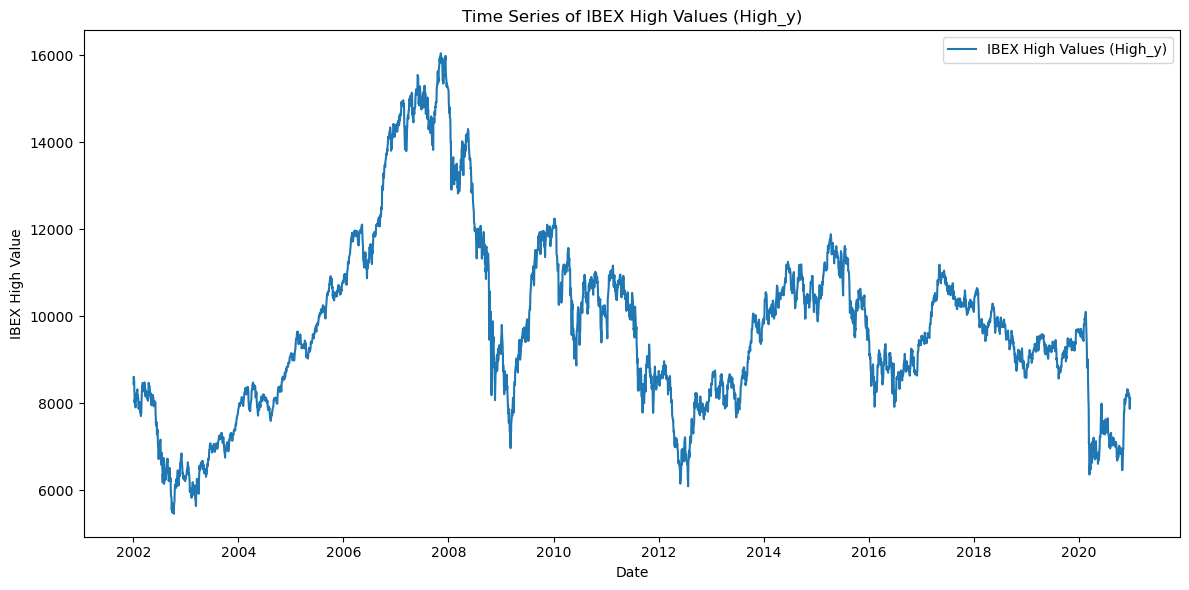

In [15]:

# Assuming 'data' is your DataFrame

# Create the 'Images' folder if it doesn't exist
images_folder = 'Images'
if not os.path.exists(images_folder):
    os.makedirs(images_folder)

# Convert 'Date' column to datetime for proper plotting
data['Date'] = pd.to_datetime(data['Date'])

# Sorting the data by Date to ensure the line is continuous
data.sort_values('Date', inplace=True)

# Time Series Plot for 'High_y'
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['High_y'], label='IBEX High Values (High_y)')
plt.title('Time Series of IBEX High Values (High_y)')
plt.xlabel('Date')
plt.ylabel('IBEX High Value')
plt.legend()
plt.tight_layout()

# Save the plot in the 'Images' folder before showing it
plt.savefig(os.path.join(images_folder, 'IBEX_High_y_timeseries.png'))

# Show the plot
plt.show()

## External factors over time

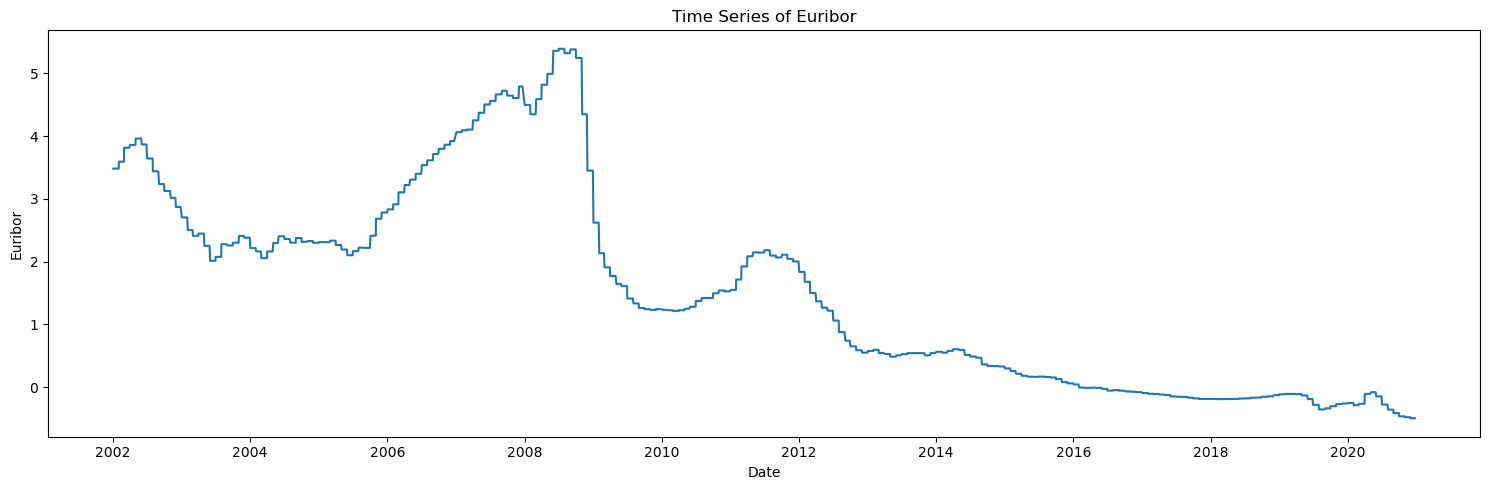

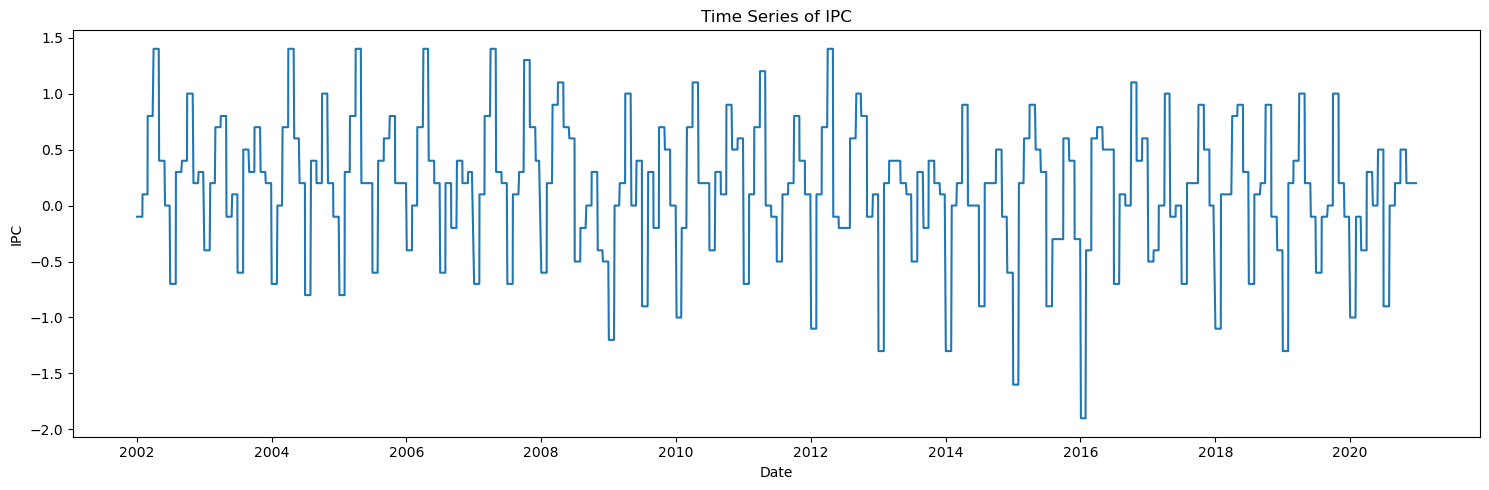

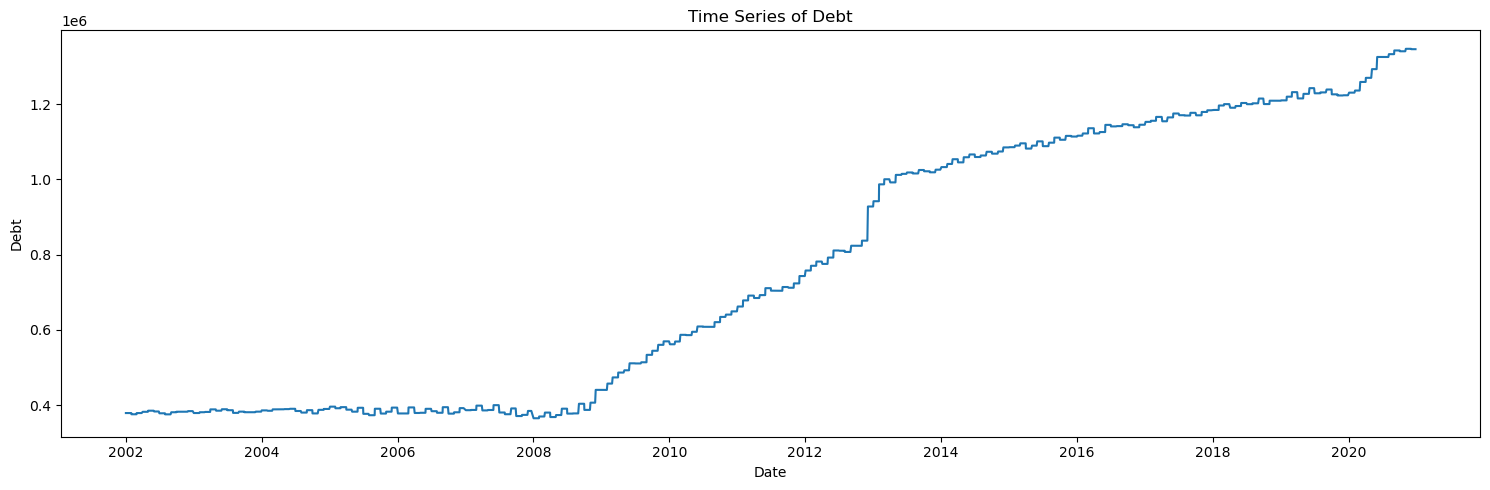

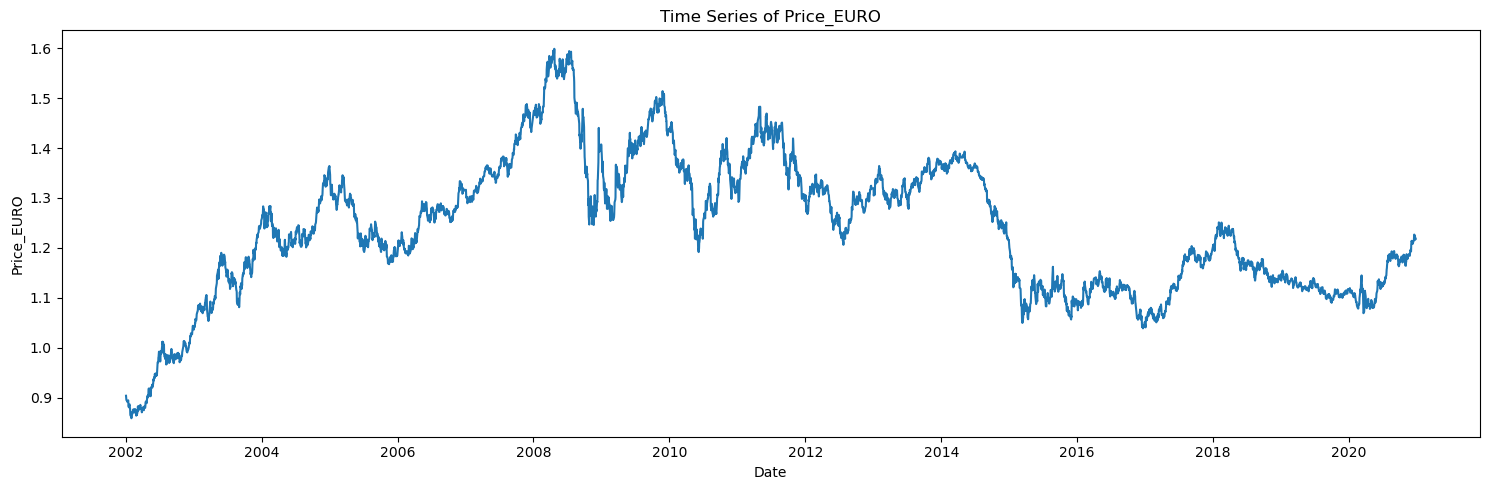

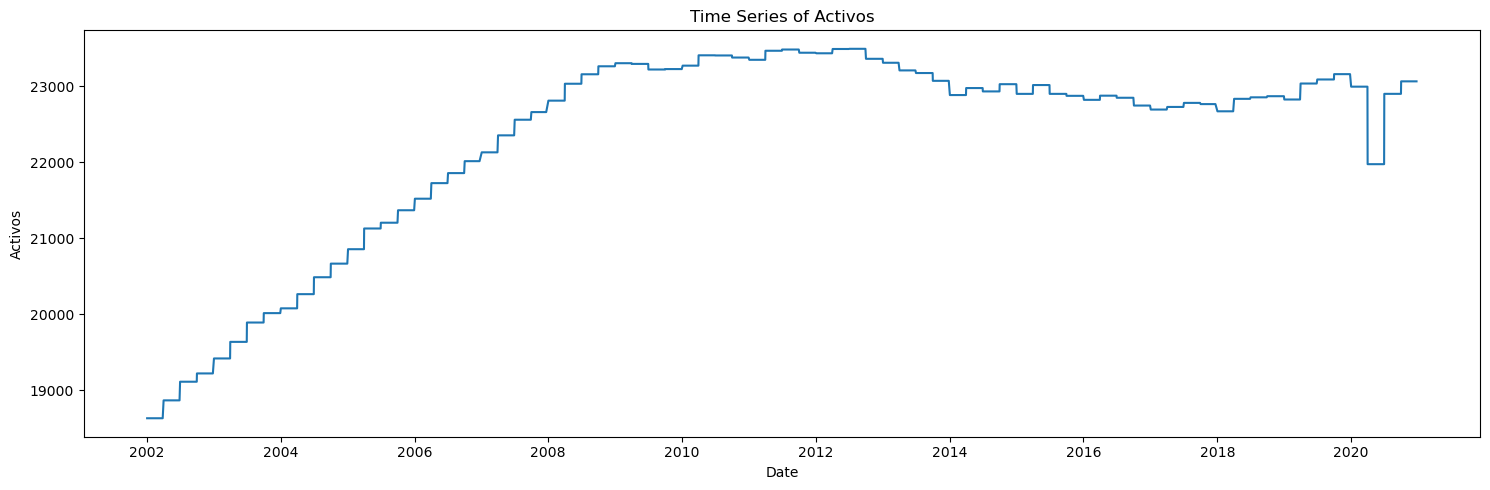

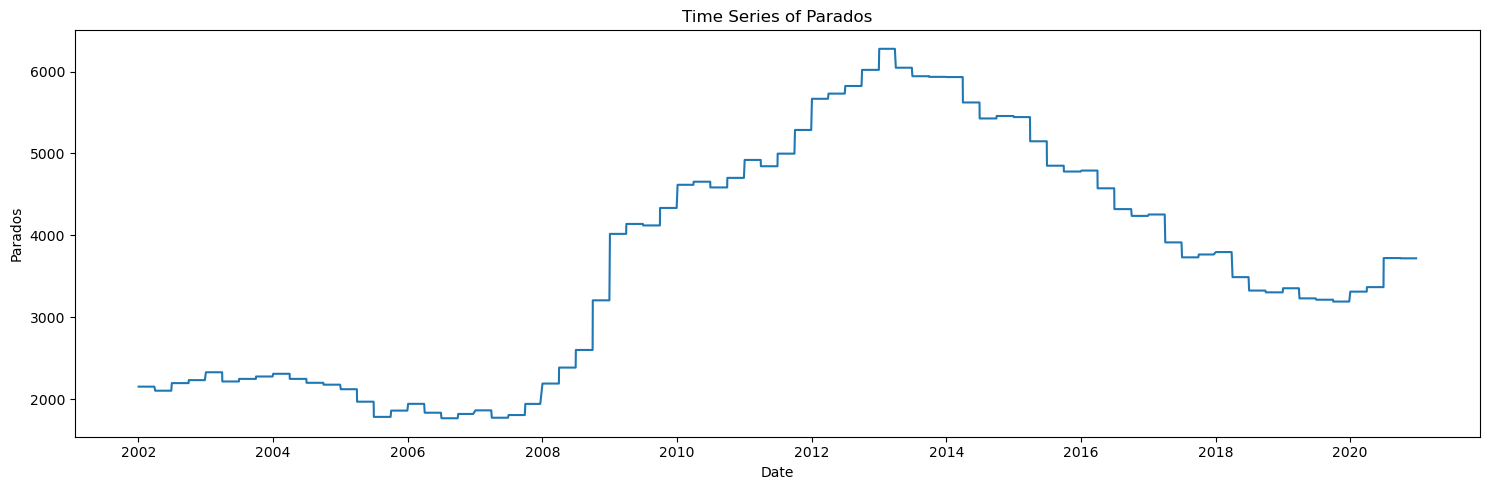

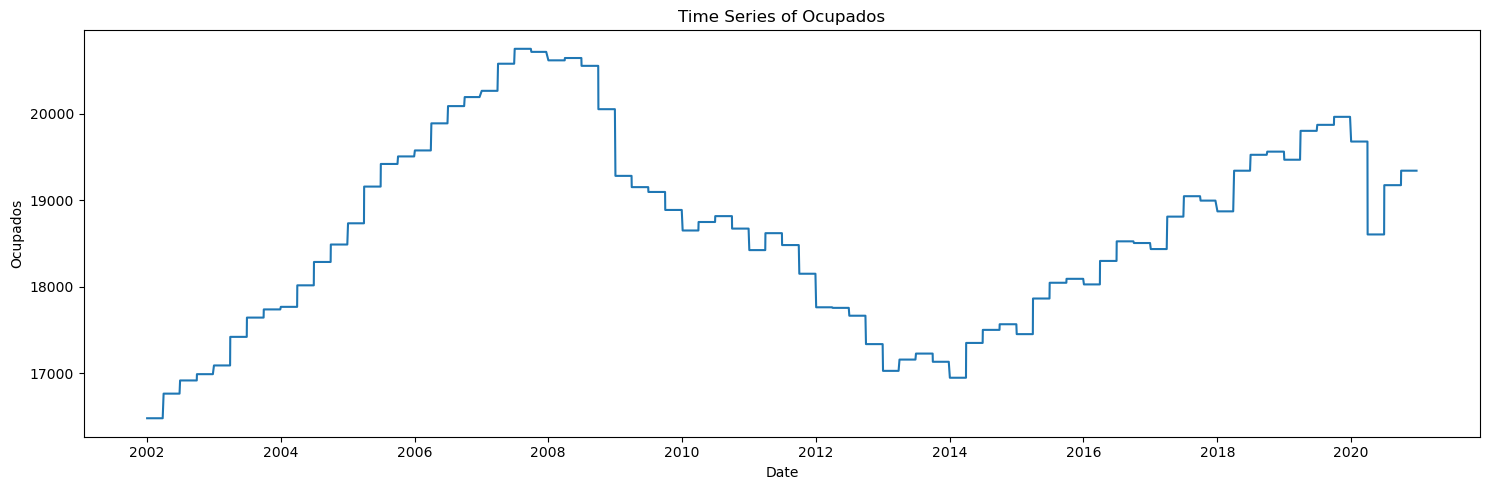

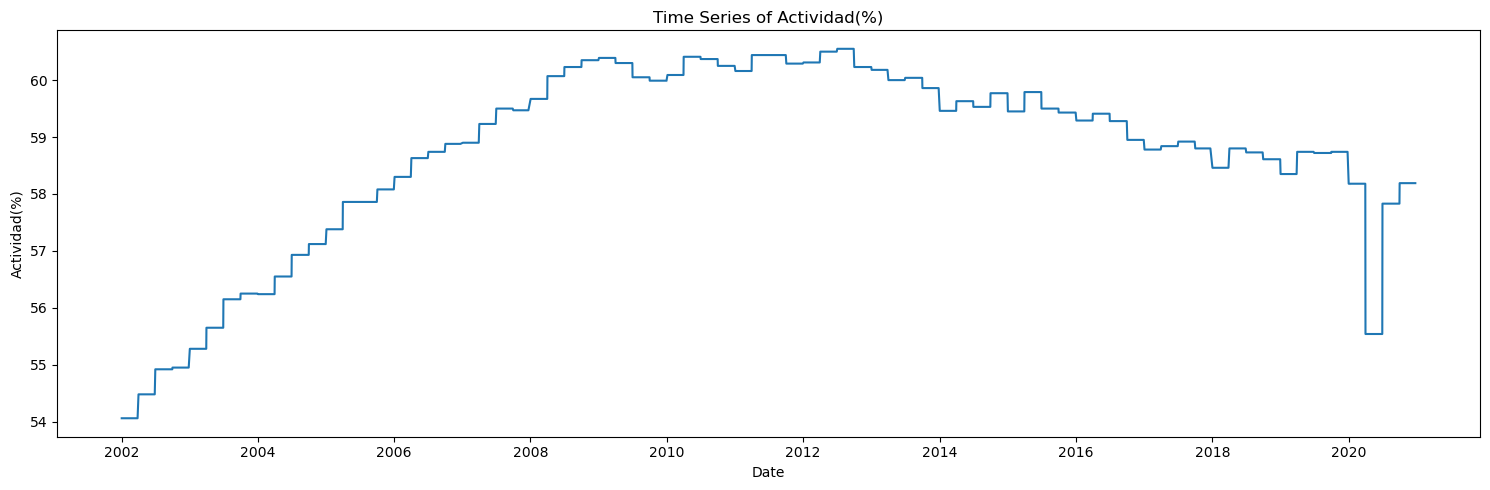

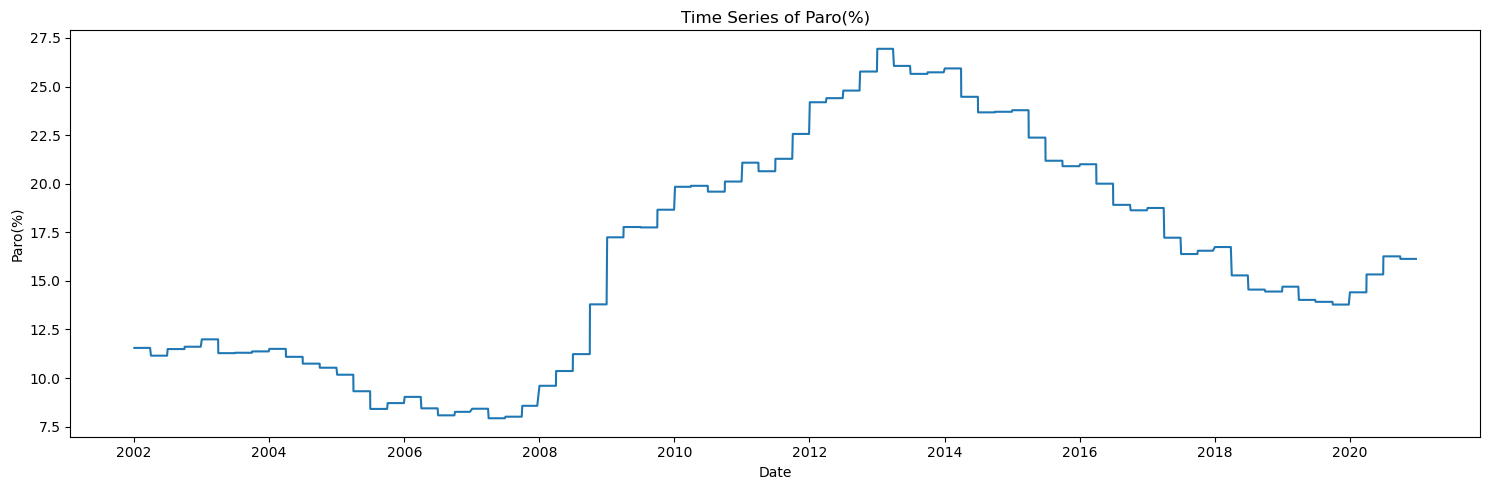

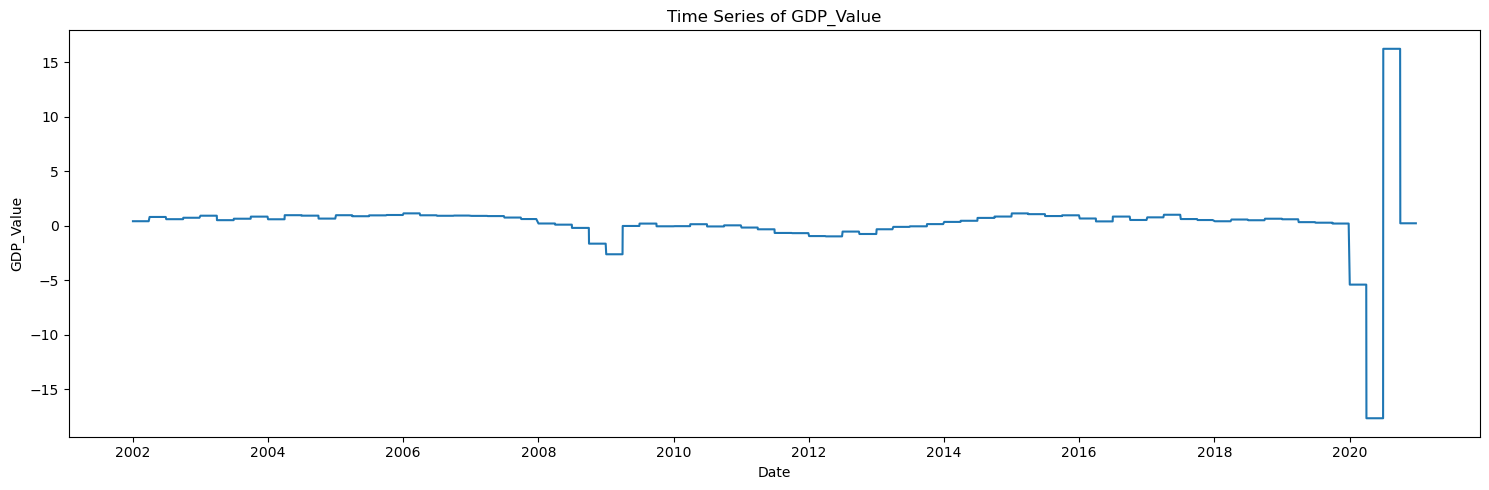

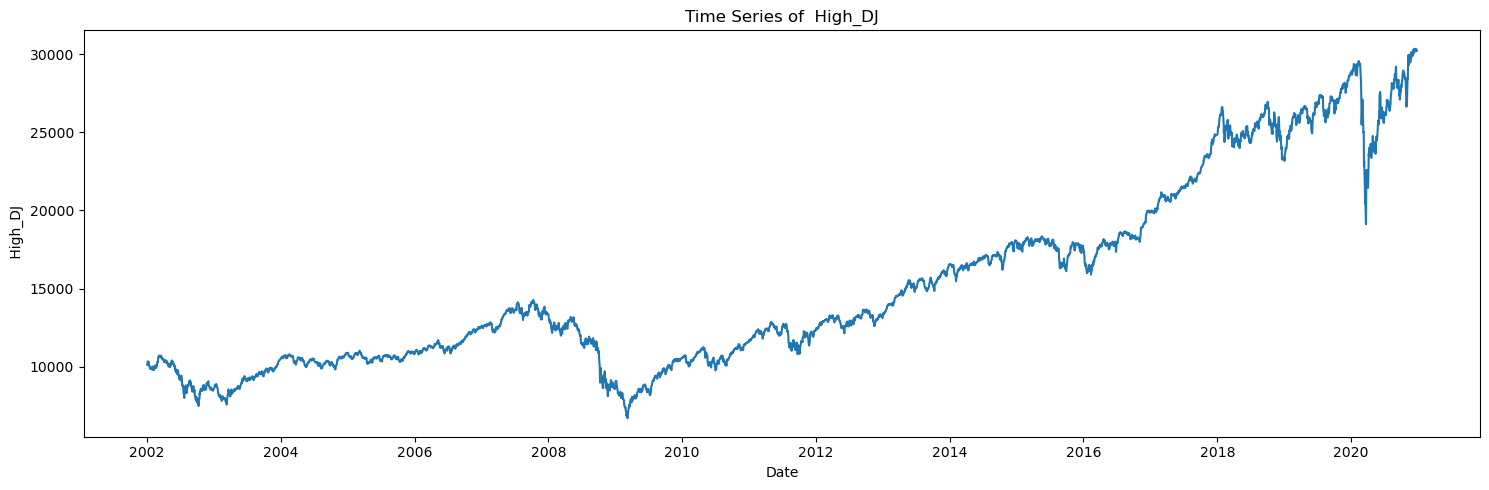

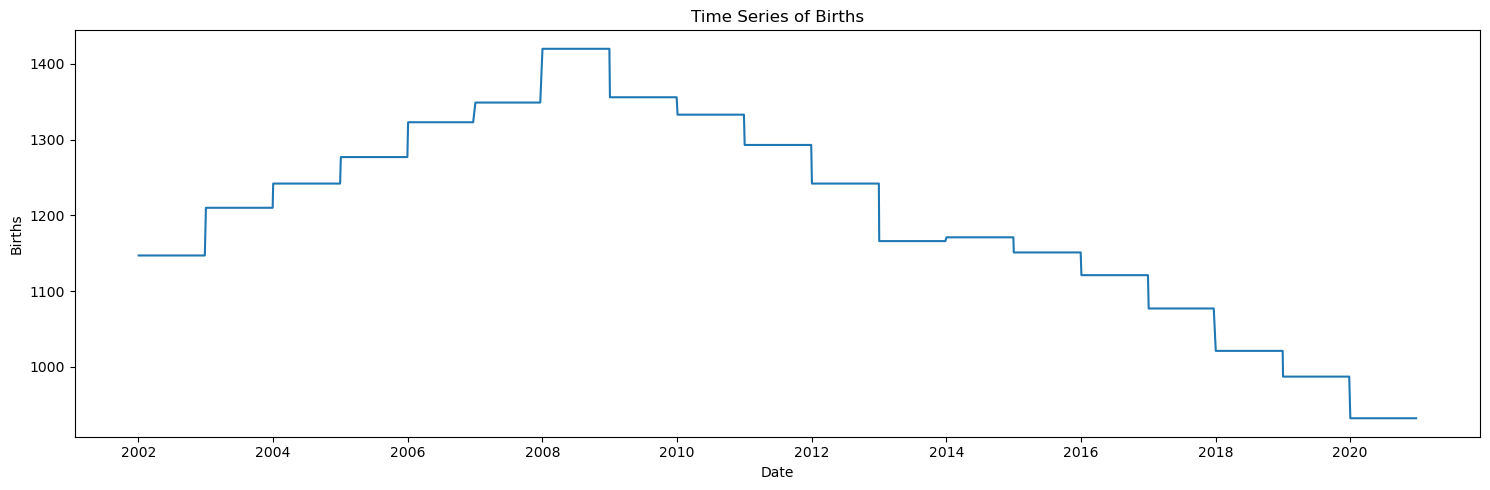

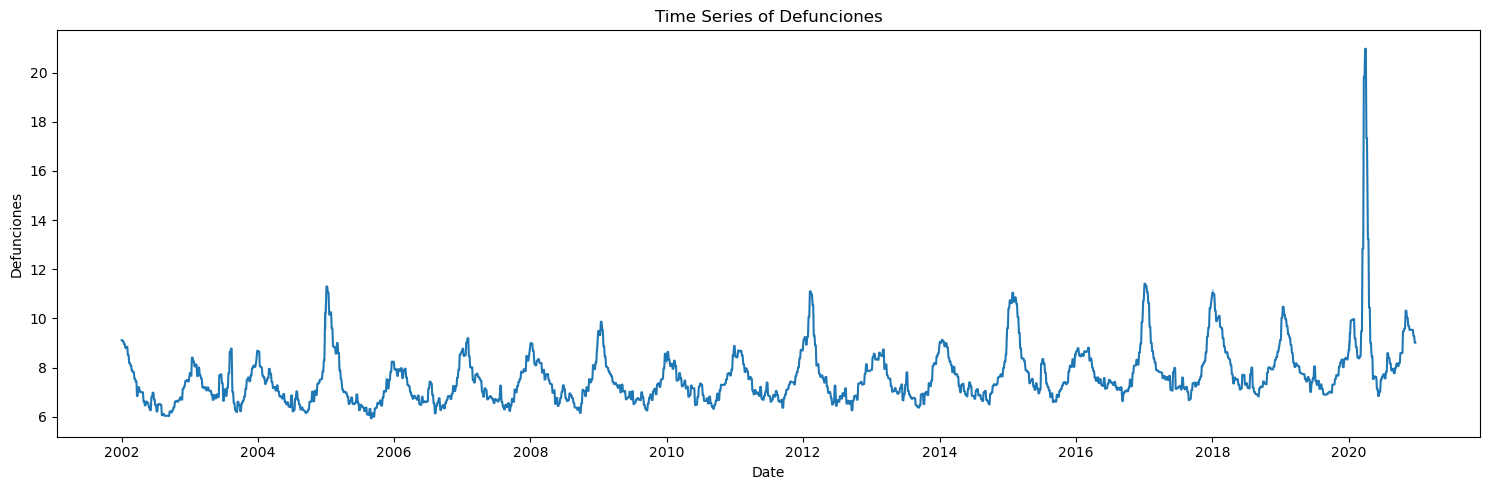

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# Assuming 'data' is your DataFrame
# Convert 'Date' column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# List of columns to plot
columns_to_plot = ['Euribor', 'IPC', 'Debt', 'Price_EURO', 'Activos', 'Parados', 'Ocupados', 'Actividad(%)', 'Paro(%)', 'GDP_Value', ' High_DJ', 'Births', 'Defunciones']

# Create the 'Images' folder if it doesn't exist
images_folder = 'Images'
if not os.path.exists(images_folder):
    os.makedirs(images_folder)

# Iterate over the list of columns
for i, col in enumerate(columns_to_plot):
    # Create a new figure for each plot
    plt.figure(figsize=(15, 5))

    # Create the line plot
    sns.lineplot(x=data['Date'], y=data[col])
    plt.title(f'Time Series of {col}')
    plt.xlabel('Date')
    plt.ylabel(col)

    # Adjust layout
    plt.tight_layout()

    # Save the figure as an image file in the 'Images' folder
    plt.savefig(os.path.join(images_folder, f'time_series_{col}.png'))

    # Show the plot
    plt.show()
    
    # Close the plot to prevent display issues
    plt.close()


## External factors comparison with ibex

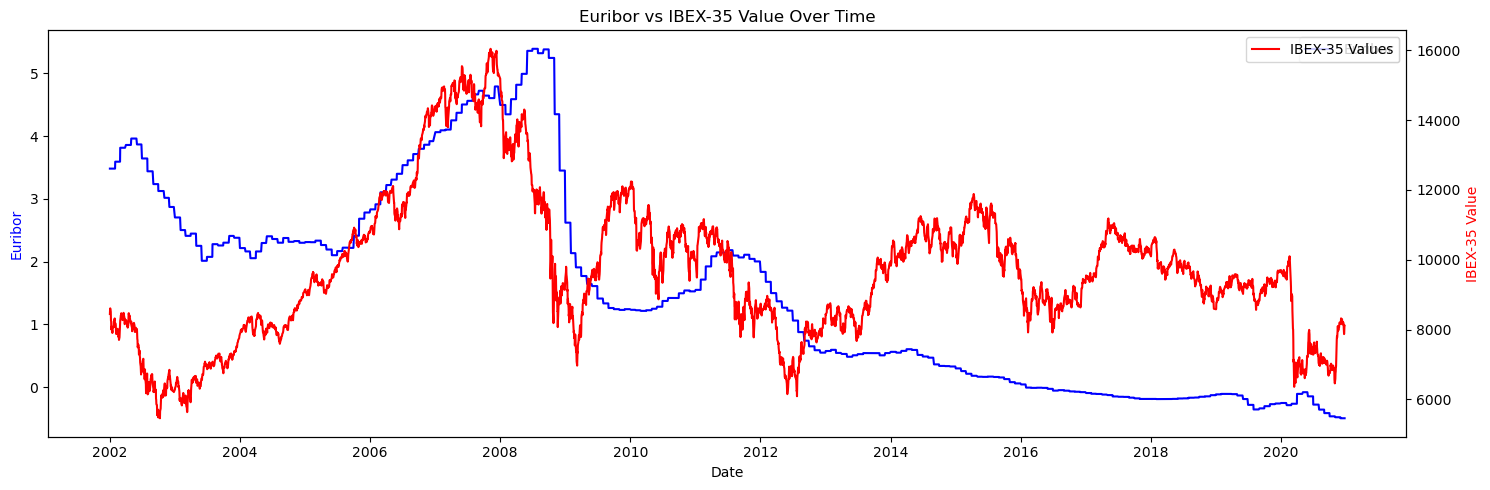

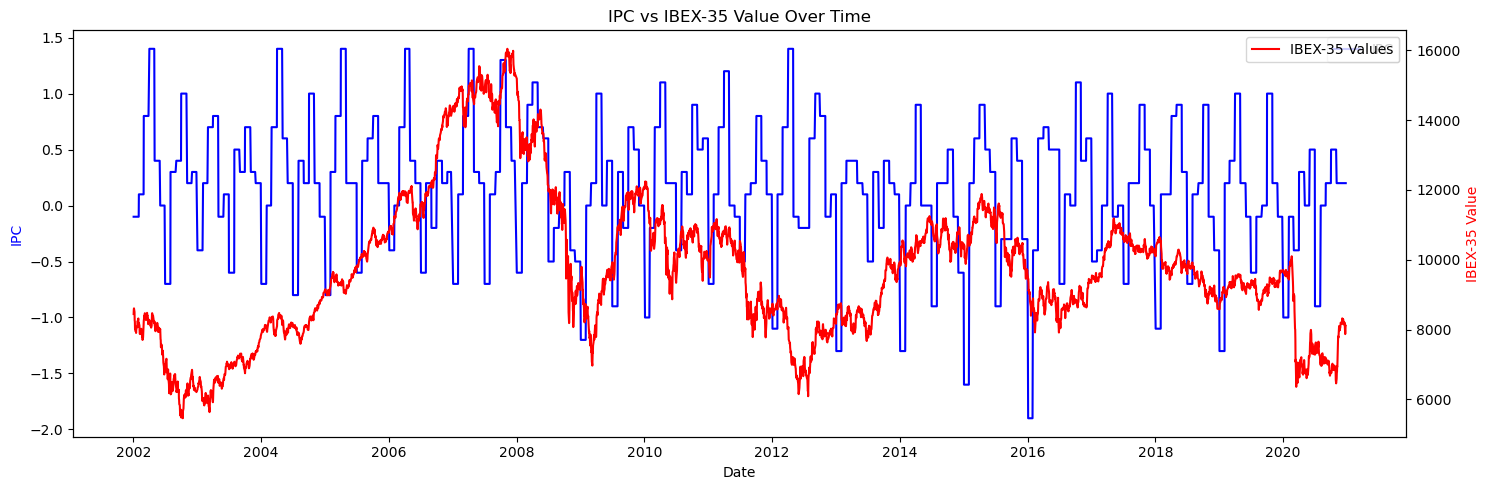

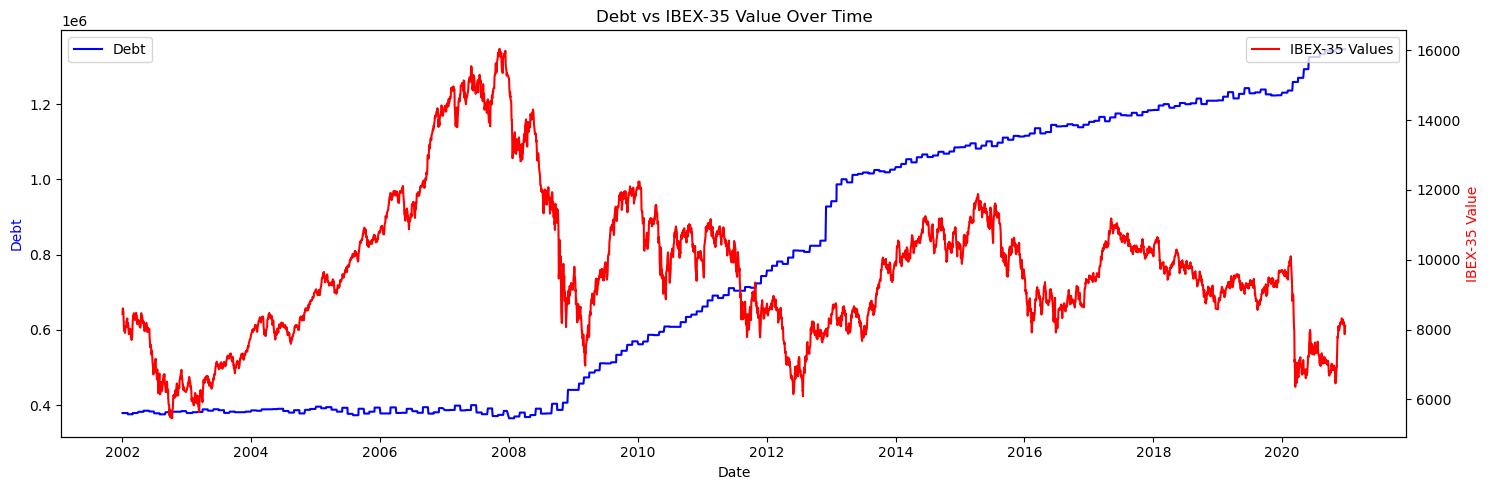

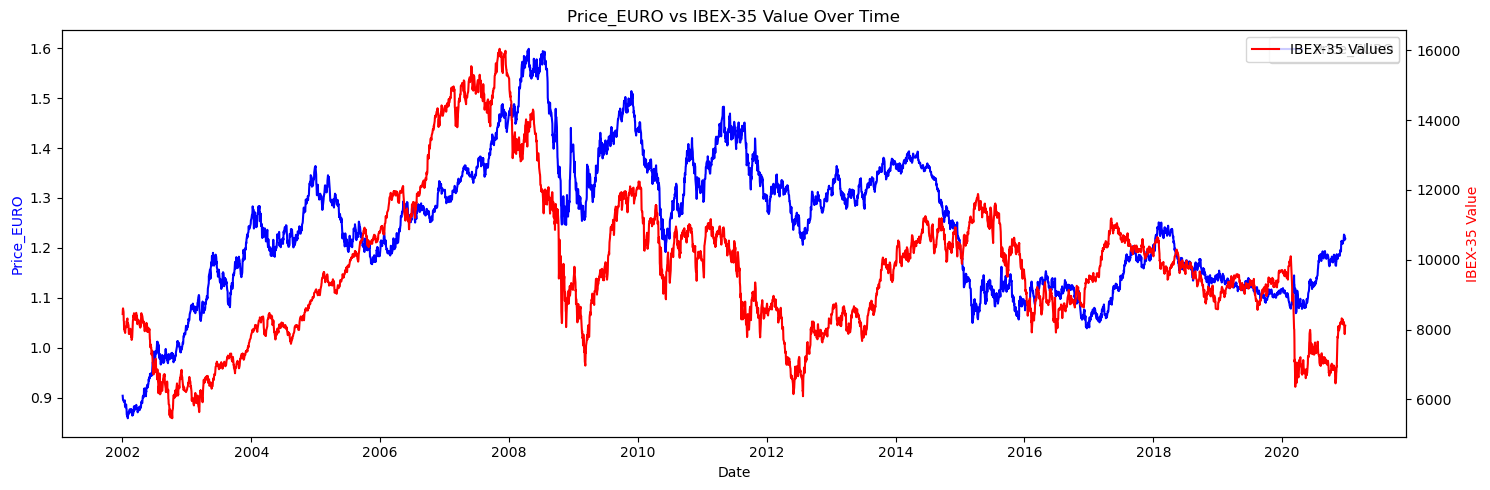

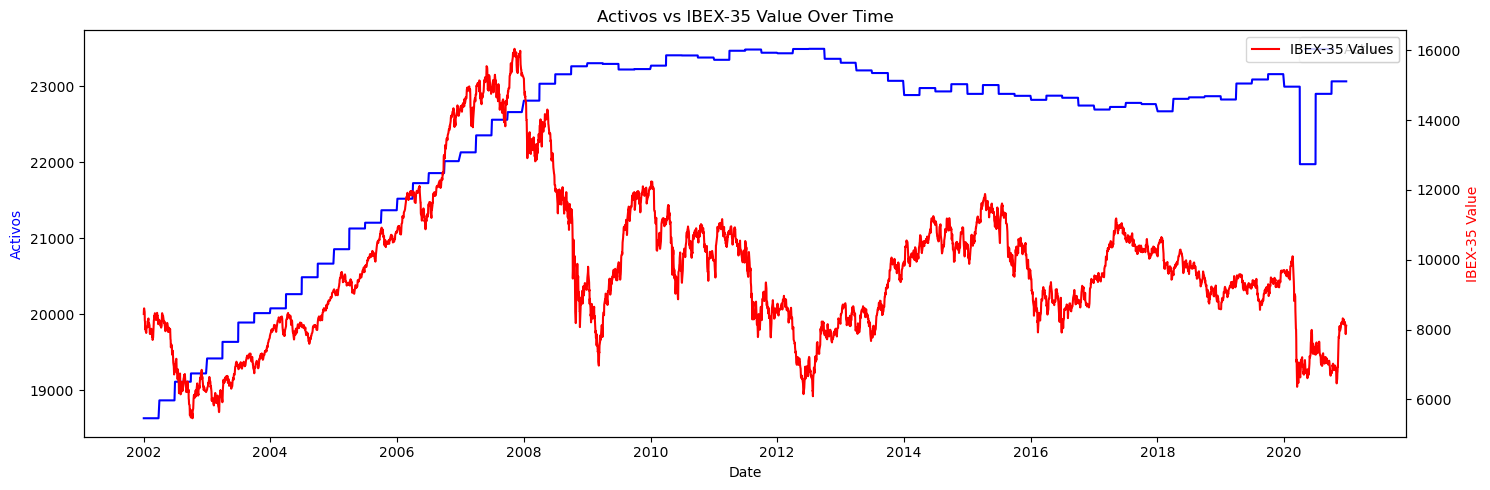

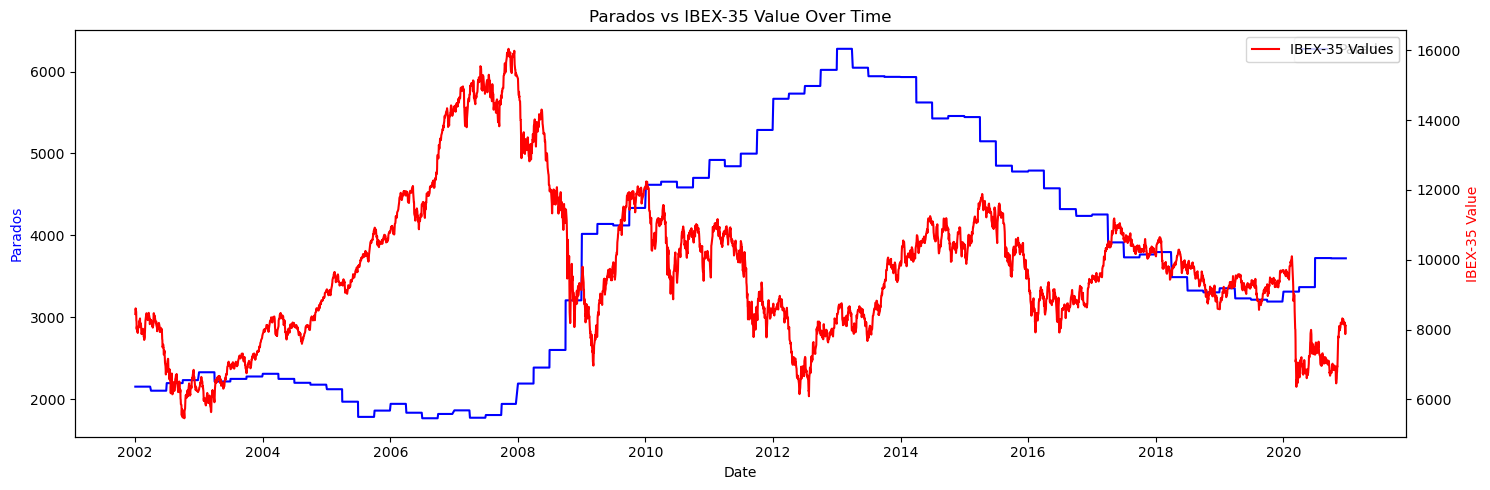

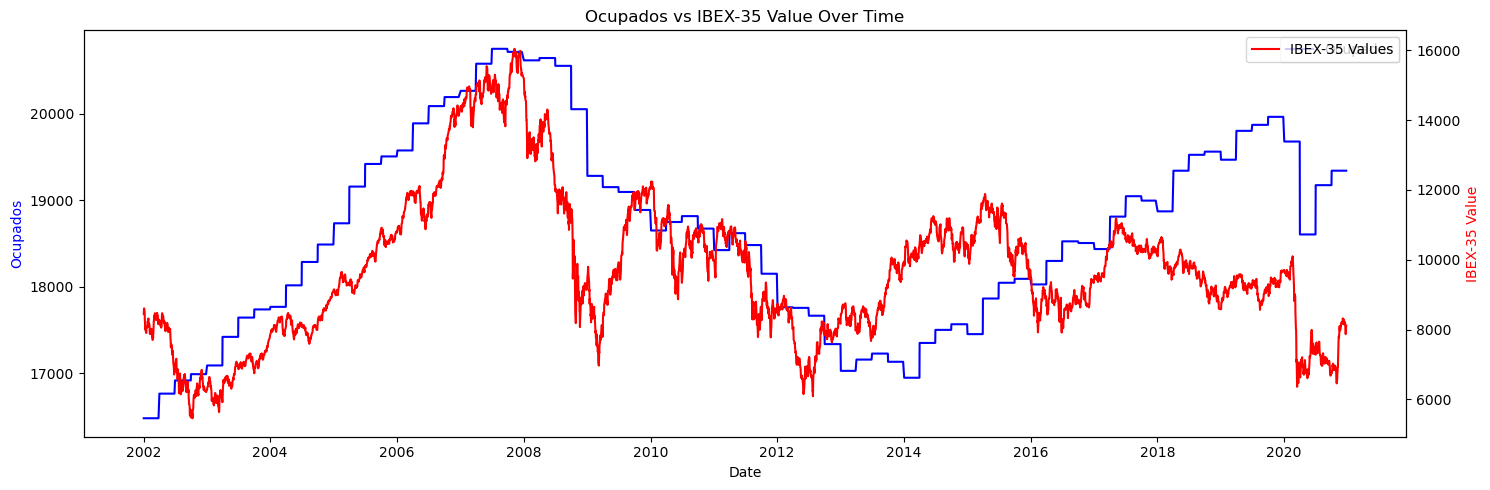

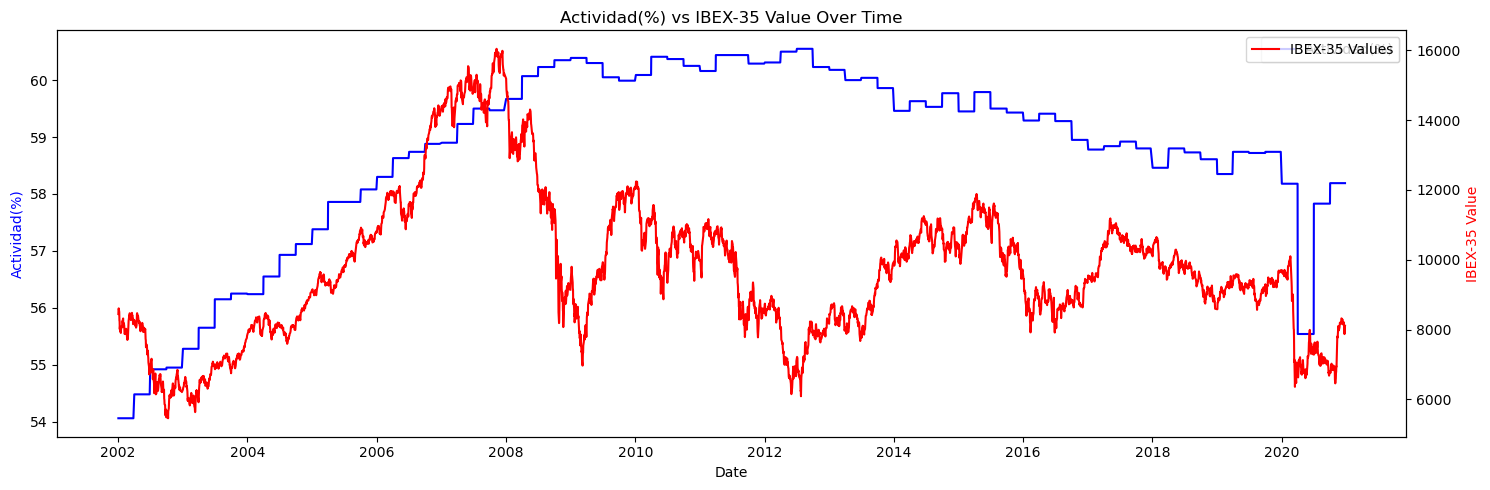

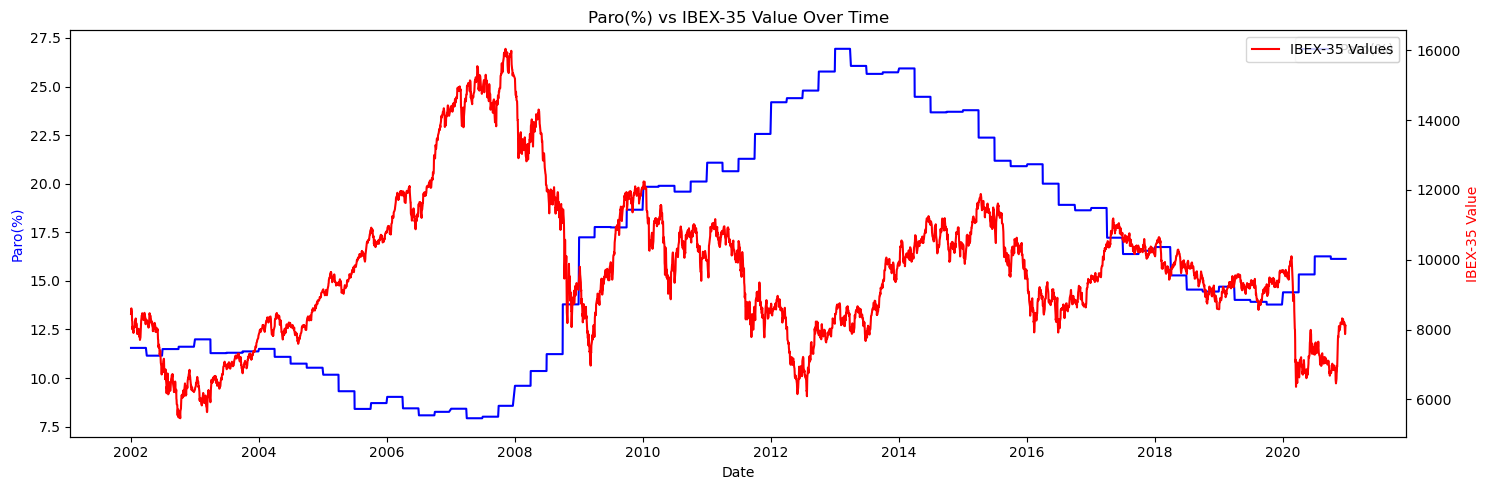

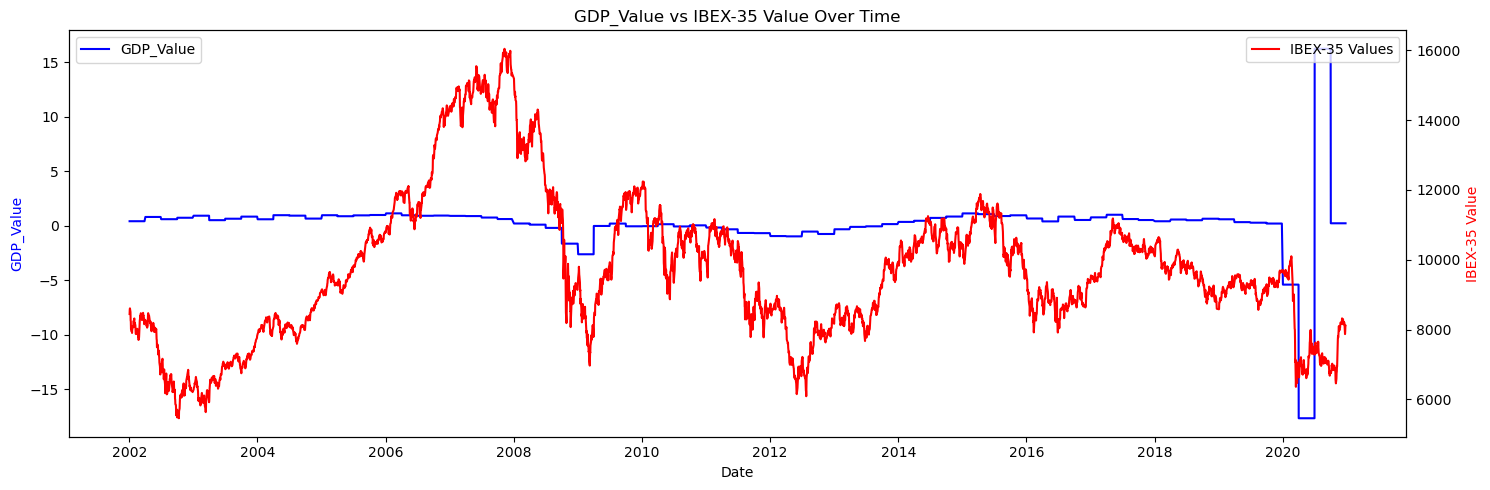

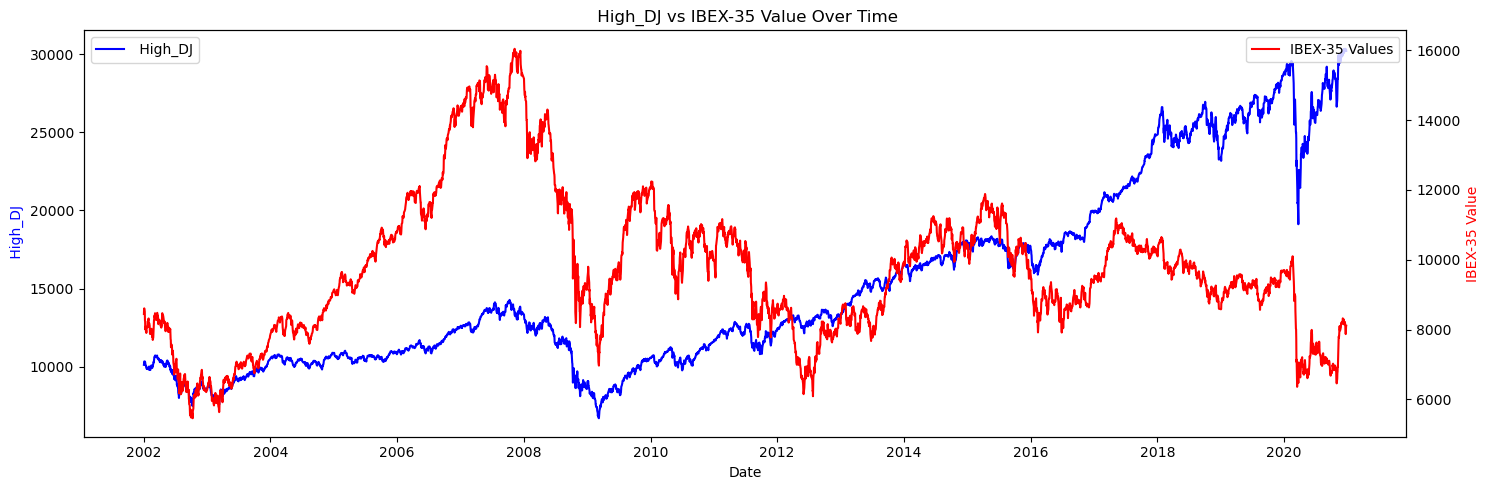

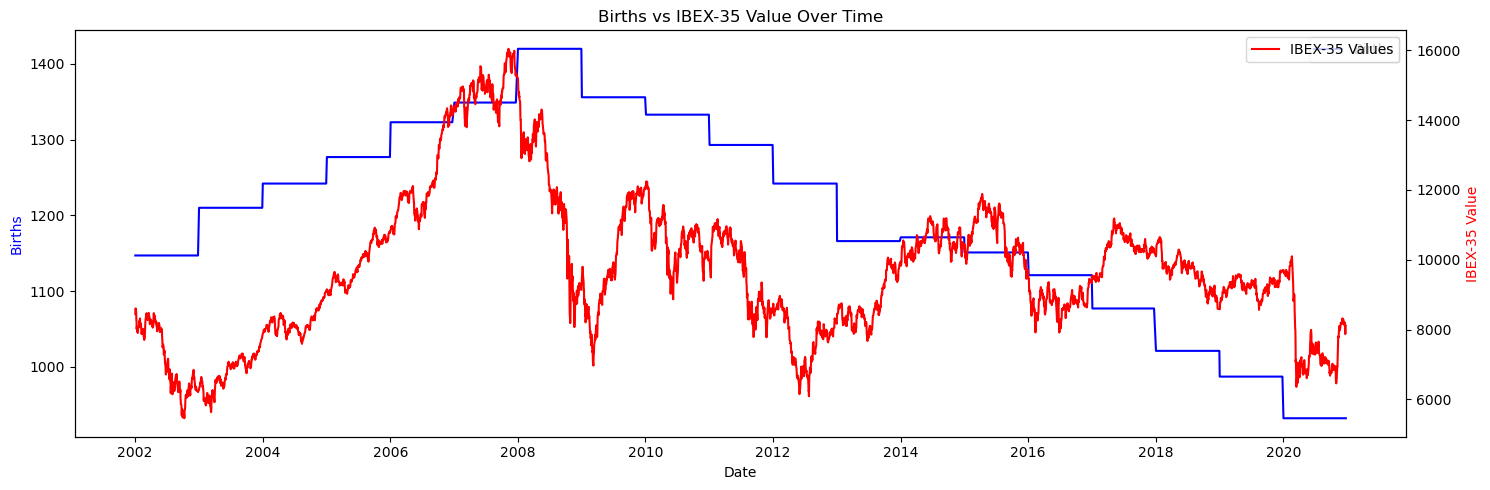

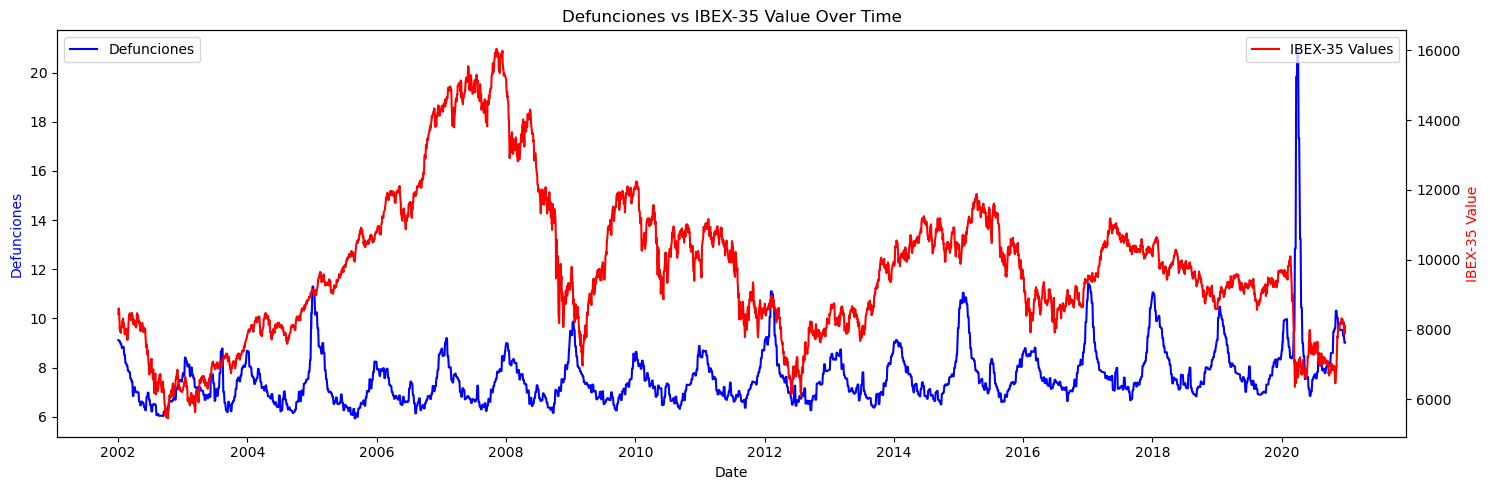

In [19]:
# Convert 'Date' column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# List of columns to compare with 'High_y'
columns_to_plot = ['Euribor', 'IPC', 'Debt', 'Price_EURO', 'Activos', 'Parados', 'Ocupados', 
                   'Actividad(%)', 'Paro(%)', 'GDP_Value', ' High_DJ', 'Births', 'Defunciones']

# Create the 'Images' folder if it doesn't exist
images_folder = 'Images'
if not os.path.exists(images_folder):
    os.makedirs(images_folder)

# Creating dual-axis line plots for each column compared with 'High_y'
for i, col in enumerate(columns_to_plot, 1):
    plt.figure(figsize=(15, 5))
    ax1 = plt.gca()
    sns.lineplot(x=data['Date'], y=data[col], ax=ax1, color='blue', label=col)
    ax1.set_ylabel(col, color='blue')
    
    ax2 = ax1.twinx()
    sns.lineplot(x=data['Date'], y=data['High_y'], ax=ax2, color='red', label='IBEX-35 Values')
    ax2.set_ylabel('IBEX-35 Value', color='red')

    plt.title(f'{col} vs IBEX-35 Value Over Time')
    plt.tight_layout()

    # Save the figure as an image file in the 'Images' folder
    plt.savefig(os.path.join(images_folder, f'{col}_vs_IBEX-35.png'))
    
    # Show the plot
    plt.show()
    
    # Close the plot to prevent display issues
    plt.close()


In [4]:
data.columns

Index(['Date', 'Births', 'Euribor', 'IPC', 'Price_EURO', 'Open_EURO',
       'High_EURO', 'Low_EURO', 'Defunciones', 'Debt', 'Percentage',
       'Debt_per_capita', 'Activos', 'Ocupados', 'Parados', 'Actividad(%)',
       'Paro(%)', 'GDP_Value', ' Open_DJ', ' High_DJ', ' Low_DJ', ' Close_DJ',
       'Open_y', 'High_y', 'Low_y', 'Close', 'AdjClose'],
      dtype='object')